# Confidence Intervals and Test Assumptions

Mathematical equivalance between confidence intervals and hypothesis tests, test assumptions (independence, normality, equal variances).

## 1. Confidence Intervals and Test Assumptions

In the previous notebook , we established the foundations of Hypothesis testing p-values, null and alternative hypothesis and test statistic. Now we explore  two complementary concepts that completed your understanding of statistical inference.

First, we'll discover that confidence intervals and hypothesis tests are mathematically equivalent. They're not two different methods for analyzing data; they're two perspectives on the same underlying calculation. Understanding this equivalence transforms how you interpret both tools.

Second, we'll examine the assumptions that make statistical tests work. Every test rests on mathematical assumptions, and when these assumptions are violated, tests can mislead you. Knowing what assumptions matter, when they matter, and what to do when they fail is essential for responsible data analysis.

## 2. Confidence Intervals: A Deeper Look

You've probably seen confidence intervals before: *"The average treatment effect was 5.2 with a 95% confidence interval of [3.1, 7.3]."* But what does this mean, and how does it connect to hypothesis testing?

### What a Confidence Interval really Means

A 95% confidence interval does NOT mean there's a 95% probability that the true parameter lies within the interval. The true parameter is fixed (though unknown). It's either inside the interval or it isn't. There's no probability involved once you've computed the interval.

>**Confidence Interval Interpreatation :**
>A 95% confidence interval means: if we repeated our sampling procedure many times and computed a confidence interval each time, 95% of those intervals would contain the true parameter value.

This is a subtle but important distinction. The confidence refers to the procedure, not to any particular interval. Over many repetitions, 95% of the intervals produced by this method will capture the true value.

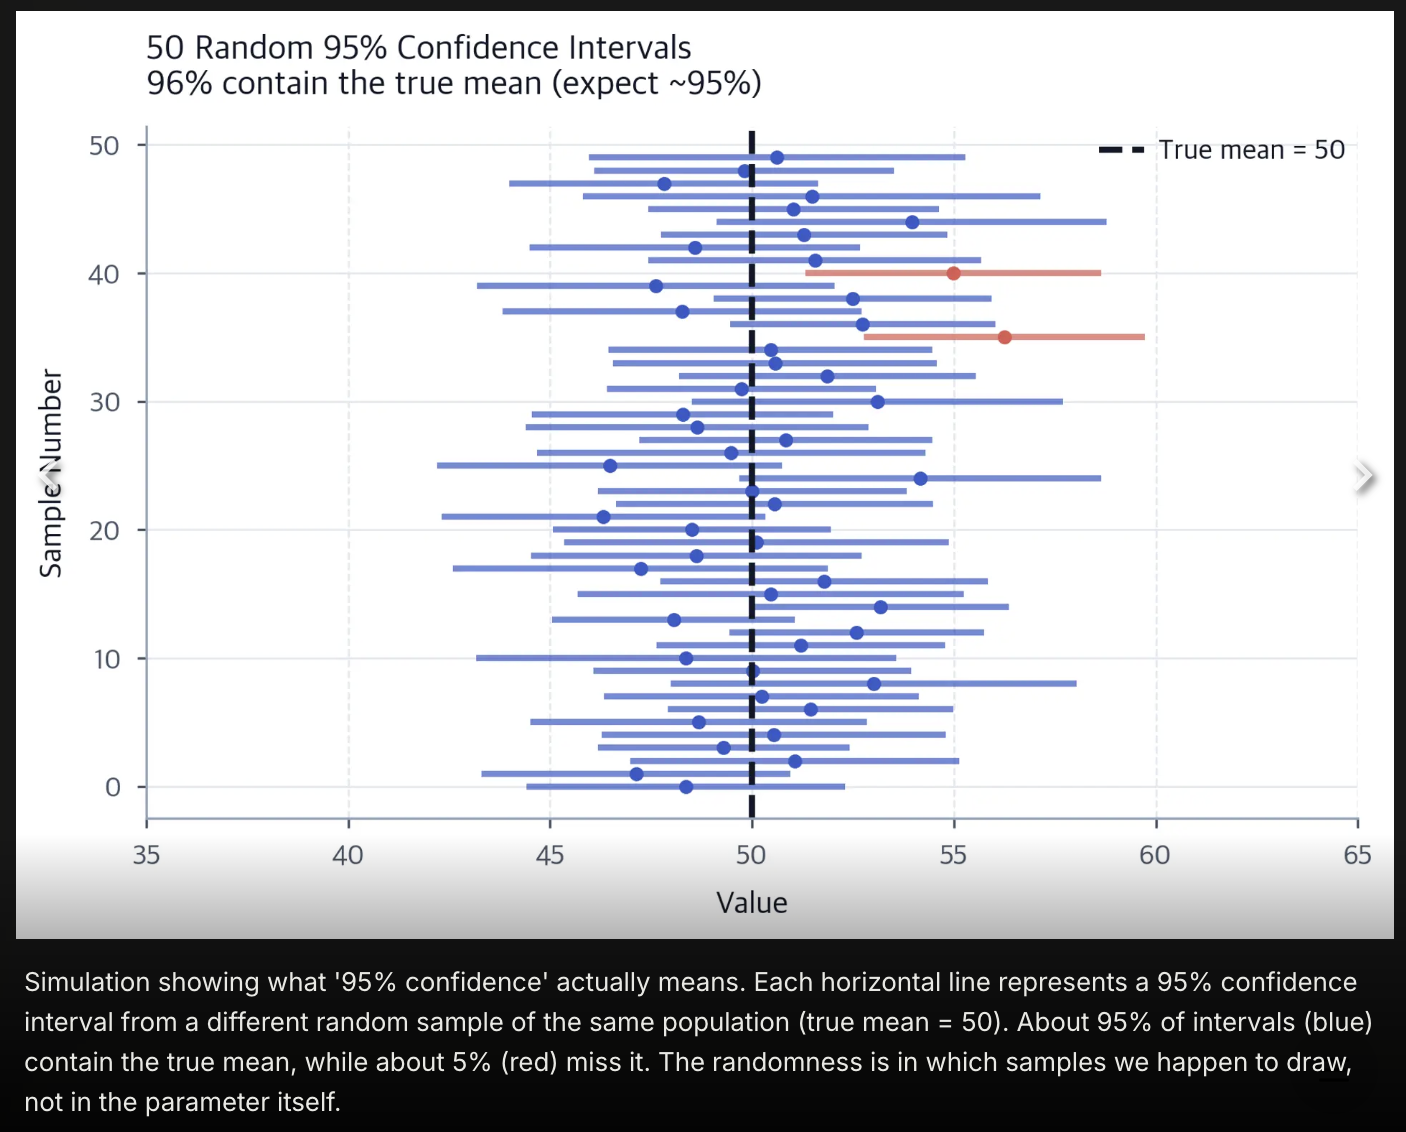


### Constructing a Confidence Interval Step By Step
Let's build a confidence interval from first principles. Suppose you have a sample of n observations and want a 
$(1− α) × 100%$
confidence interval for the population mean.

**Step 1: Calculate the Sample Mean**

$$\hat{x} = \frac{1}{n} \sum_{i=1}^{n}{x_i}$$

**Step 2: Calculate the Standard Error**

The standard error measures how much the sample mean varies from sample to sample. If you know the population standard deviation $σ$:

$$SE = \frac{\sigma}{\sqrt(n)}$$

If you don't know $\sigma$ , estimate it with the sample standard deviation :

$$SE = \frac{\sigma}{\sqrt(n)} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}[{x_i - \hat{x}}]^2}$$

**Step 3 : Find the Critical Value**:

For a 95% confidence interval ($α= 0.05$), you need the value that cuts off 2.5% in each tail of the distribution.

If you know $\sigma$ use the $z$ critical value : $z_{1- \frac{\alpha}{2} = z_{0.975} =. 1.96}$

**Step 4: Construct the interval**



In [2]:
import numpy as np
from scipy import stats

# Sample Data: reaction time in milliseconds
reaction_times = np.array(
    [
        245,
        268,
        252,
        241,
        259,
        263,
        248,
        271,
        255,
        249,
        262,
        247,
        258,
        244,
        266,
        253,
        260,
        242,
        257,
        251,
    ]
)

#Step 1: Sample mean
n = len(reaction_times)
sample_mean = np.mean(reaction_times)

#Step 2: Standard Error
sample_std = np.std(reaction_times, ddof=1)
standard_error = sample_std / np.sqrt(n)


# Step 3: Critical Value of 95% CI
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df = n-1)

# Step 4: Construct the interval
margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Sample size: n = {n}")
print(f"Sample mean: x̄ = {sample_mean:.2f} ms")
print(f"Sample std: s = {sample_std:.2f} ms")
print(f"Standard error: SE = {standard_error:.2f} ms")
print(f"t critical value (df={n - 1}): t = {t_critical:.3f}")
print(f"Margin of error: {margin_of_error:.2f} ms")
print(f"\n95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}] ms")



Sample size: n = 20
Sample mean: x̄ = 254.55 ms
Sample std: s = 8.80 ms
Standard error: SE = 1.97 ms
t critical value (df=19): t = 2.093
Margin of error: 4.12 ms

95% Confidence Interval: [250.43, 258.67] ms
